# Stock Price Forecasting - Apple (AAPL)

## Objective
Analyze the historical price of Apple stock and forecast the next 365 days using **Prophet**, a time series forecasting library developed by Facebook.

## What is a time series?
A time series is any data recorded over time — stock prices, monthly sales, temperature. The goal is to find patterns in the past (trend, seasonality) and use them to predict the future.

## Why Prophet?
Prophet is designed for business forecasting. It handles trends, seasonality and missing data automatically, and is widely used in industry for sales, traffic and financial forecasting.

## Dataset
- `aapl_stock_prices.csv`: daily AAPL closing prices from 1980 to present
- Columns: `Date`, `Open`, `High`, `Low`, `Close`, `Volume`

## 1. Imports

- `pandas`: data manipulation
- `matplotlib`: visualizations
- `Prophet`: time series forecasting algorithm

If Prophet is not installed, run `!pip install prophet` in a separate cell first.

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet

## 2. Loading the data

Loading the CSV and displaying the first rows to confirm the structure. The dataset contains daily AAPL prices going back to 1980.

In [27]:
df = pd.read_csv("aapl_stock_prices.csv")

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print()
df.head()

Shape: (11407, 6)
Columns: ['Date', 'Open', 'High', 'Low', 'Close', 'Volume']



,Date,Open,High,Low,Close,Volume
0,1980-12-12,0.098297,0.098725,0.098297,0.098297,469033600
1,1980-12-15,0.093597,0.093597,0.093169,0.093169,175884800
2,1980-12-16,0.086758,0.086758,0.086331,0.086331,105728000
3,1980-12-17,0.088468,0.088895,0.088468,0.088468,86441600
4,1980-12-18,0.091032,0.091460,0.091032,0.091032,73449600


## 3. Data preparation

Prophet requires a very specific input format:
- A column named `ds` containing the dates
- A column named `y` containing the values to forecast

We use the `Close` price as the target — it represents the final price of the stock at the end of each trading day.

The `Date` column is converted to datetime format so Prophet can correctly interpret the time intervals.

In [28]:
df_prophet = df[["Date", "Close"]].copy()
df_prophet.columns = ["ds", "y"]
df_prophet["ds"] = pd.to_datetime(df_prophet["ds"])

print("Shape: ", df_prophet.shape)
print("Date range:", df_prophet["ds"].min(), "to", df_prophet["ds"].max())
df_prophet.head()

Shape:  (11407, 2)
Date range: 1980-12-12 00:00:00 to 2026-03-18 00:00:00


,ds,y
0,1980-12-12,0.098297
1,1980-12-15,0.093169
2,1980-12-16,0.086331
3,1980-12-17,0.088468
4,1980-12-18,0.091032


## 4. Exploratory analysis

Plotting the full historical closing price to understand the trend before training the model. This helps identify major growth periods and any anomalies in the data.

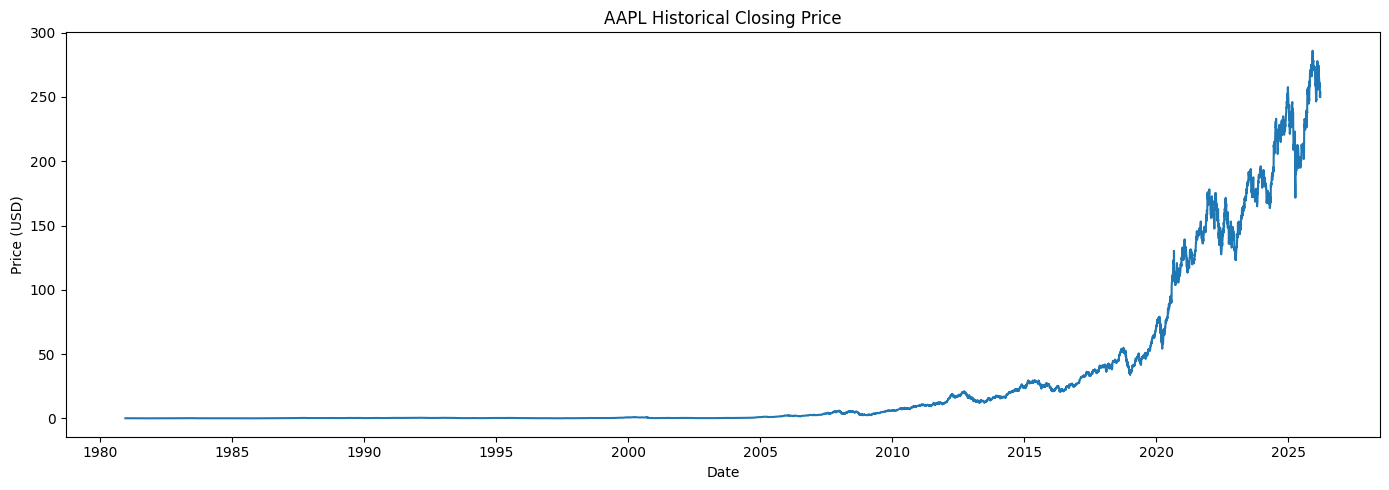

In [29]:
plt.figure(figsize=(14, 5))
plt.plot(df_prophet["ds"], df_prophet["y"])
plt.title("AAPL Historical Closing Price")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.tight_layout()
plt.show()

## 5. Using recent data only

The full dataset goes back to 1980, when Apple's stock price was below $0.10. Including that data would confuse the model — the growth patterns from 40 years ago are not representative of today's behavior.

We filter to keep only the last 5 years, which gives the model a more relevant and recent view of the stock's behavior.

Shape after filtering: (1812, 2)
Date range: 2019-01-02 00:00:00 to 2026-03-18 00:00:00


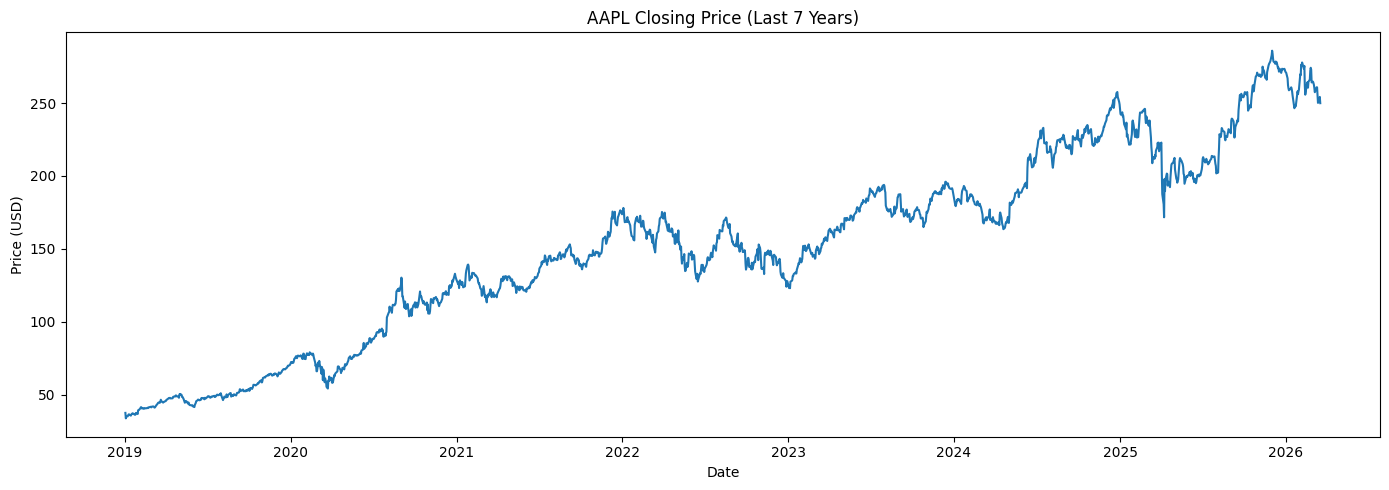

In [30]:
df_prophet = df_prophet[df_prophet["ds"] >= "2019-01-01"].reset_index(drop=True)

print("Shape after filtering:", df_prophet.shape)
print("Date range:", df_prophet["ds"].min(), "to", df_prophet["ds"].max())

plt.figure(figsize=(14, 5))
plt.plot(df_prophet["ds"], df_prophet["y"])
plt.title("AAPL Closing Price (Last 7 Years)")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.tight_layout()
plt.show()

## 6. Training the Prophet model

Prophet automatically detects:
- **Trend**: the overall direction of the price over time
- **Yearly seasonality**: patterns that repeat every year
- **Weekly seasonality**: patterns that repeat every week (e.g. stock markets are closed on weekends)

`daily_seasonality=False` is set because stock prices do not have meaningful intraday patterns in daily data.

In [31]:
model = Prophet(daily_seasonality=False)
model.fit(df_prophet)

print("Model trained successfully")

Model trained successfully


## 7. Creating future dates

`make_future_dataframe` creates a DataFrame with future dates for the model to predict. `periods=365` means we are forecasting the next 365 days beyond the last date in the training data.

In [32]:
future = model.make_future_dataframe(periods=365)


print("Future dataframe shape:", future.shape)
future.tail()

Future dataframe shape: (2177, 1)


,ds
2172,2027-03-14
2173,2027-03-15
2174,2027-03-16
2175,2027-03-17
2176,2027-03-18


## 8. Generating the forecast

`model.predict` generates predictions for all dates — both historical (to validate the model) and future.

The output contains:
- `yhat`: the predicted value
- `yhat_lower`: lower bound of the confidence interval
- `yhat_upper`: upper bound of the confidence interval

The confidence interval shows the range of uncertainty — wider intervals mean the model is less confident about that prediction.

In [33]:
forecast = model.predict(future)

print("Forecast Shape:", forecast.shape)
forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].tail(10)

Forecast Shape: (2177, 19)


,ds,yhat,yhat_lower,yhat_upper
2167,2027-03-09,278.815000,246.403804,310.228017
2168,2027-03-10,278.511279,245.211281,309.570051
2169,2027-03-11,278.061435,246.895842,311.222581
2170,2027-03-12,278.025348,244.513773,310.497430
2171,2027-03-13,275.988081,243.261507,307.830630
2172,2027-03-14,275.876193,242.179110,306.018830
2173,2027-03-15,277.899974,243.172656,310.927454
2174,2027-03-16,277.734811,243.349490,310.603445
2175,2027-03-17,277.683257,242.566888,309.443189
2176,2027-03-18,277.464181,242.065529,310.996106


## 9. Visualizing the forecast

Prophet has a built-in plot function that shows:
- Black dots: actual historical prices
- Blue line: model prediction
- Light blue area: confidence interval (uncertainty range)

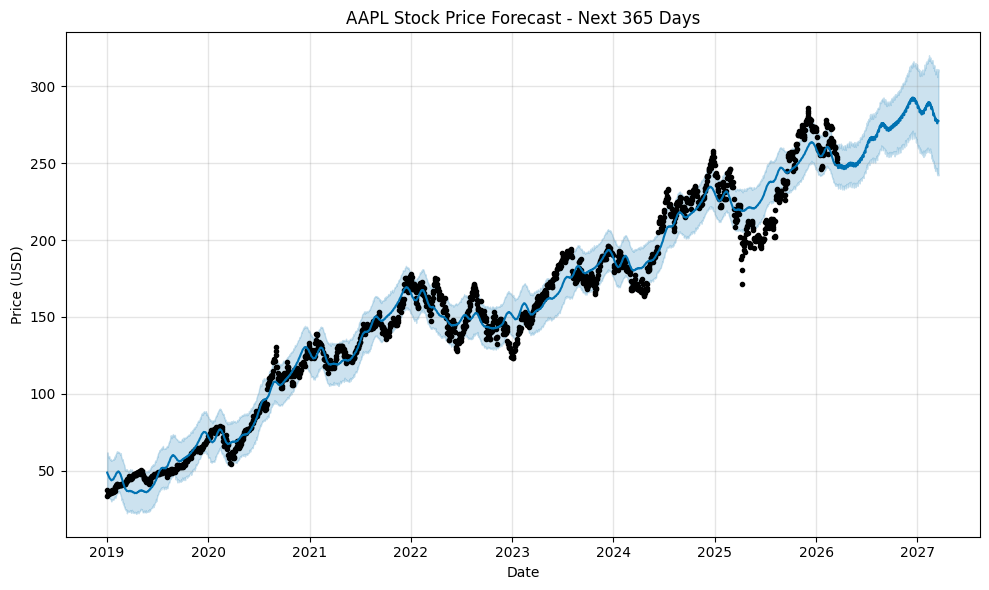

In [34]:
fig = model.plot(forecast)
plt.title("AAPL Stock Price Forecast - Next 365 Days")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.tight_layout()
plt.show()

## 10. Decomposing the forecast components

Prophet separates the forecast into its individual components:
- **Trend**: the long-term direction of the price
- **Weekly seasonality**: how the price behaves on different days of the week
- **Yearly seasonality**: how the price behaves across different months of the year

This decomposition is one of the main advantages of Prophet over other methods — it makes the model interpretable.

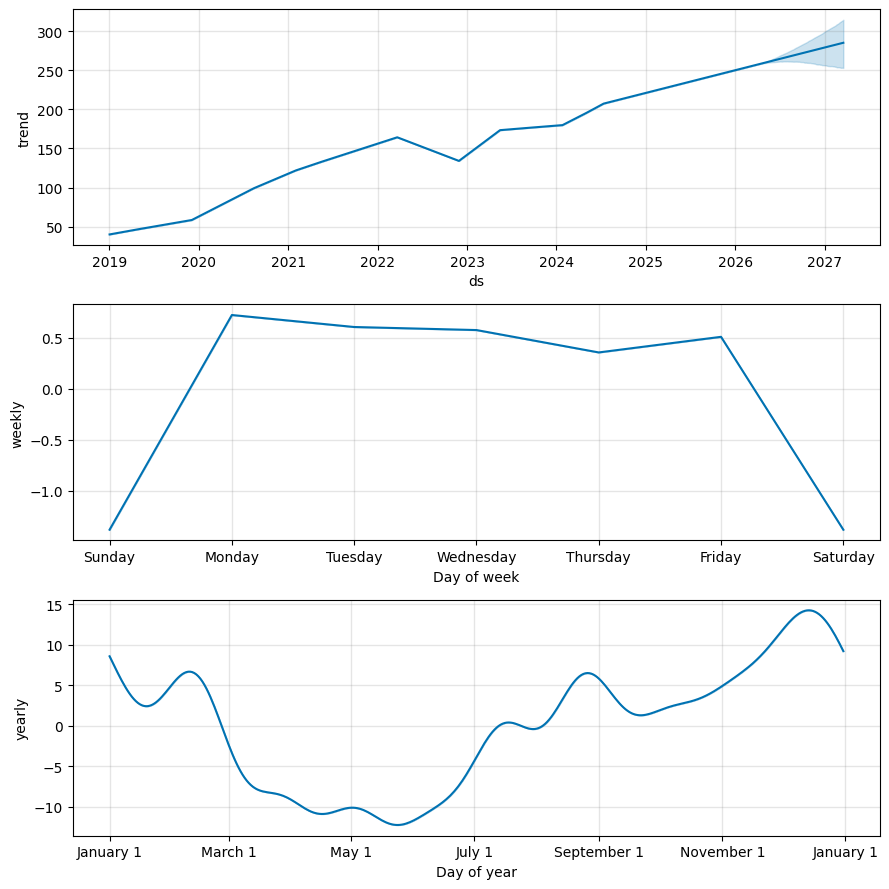

In [35]:
fig = model.plot_components(forecast)
plt.tight_layout()
plt.show()

## 11. Forecast summary

Displaying the predicted price for the next 30 days with the confidence interval.

In [36]:
last_date = df_prophet["ds"].max()
next_30 = forecast[forecast["ds"] > last_date][["ds", "yhat", "yhat_lower", "yhat_upper"]].head(30)

next_30.columns = ["Date", "Predicted Price", "Lower Bound", "Upper Bound"]
next_30 = next_30.reset_index(drop=True)

print("Predicted AAPL price for the next 30 days:")
print(next_30.to_string(index=False))



Predicted AAPL price for the next 30 days:
      Date  Predicted Price  Lower Bound  Upper Bound
2026-03-19       248.444882   235.450208   261.450678
2026-03-20       248.629996   236.025763   262.278885
2026-03-21       246.781165   233.481925   259.781347
2026-03-22       246.823411   233.988171   259.180648
2026-03-23       248.966388   236.750615   262.480579
2026-03-24       248.885742   236.658492   262.592792
2026-03-25       248.885146   235.383507   262.139322
2026-03-26       248.685407   236.087073   261.637810
2026-03-27       248.845822   235.766890   261.022118
2026-03-28       246.952231   233.842619   260.316245
2026-03-29       246.933272   233.285396   259.805590
2026-03-30       249.002517   236.322993   261.537681
2026-03-31       248.839724   236.639152   262.806627
2026-04-01       248.752752   235.526770   261.537072
2026-04-02       248.466551   235.587490   262.112385
2026-04-03       248.544410   235.364410   260.753948
2026-04-04       246.575894   234.13459

## Conclusions

- The Prophet model was trained on 7 years of AAPL daily closing prices.
- The model identified the long-term upward trend and yearly seasonality patterns.
- The forecast for the next 365 days includes a confidence interval that widens over time, reflecting increasing uncertainty the further into the future we predict.
- Stock price forecasting is inherently uncertain — external events (earnings reports, macroeconomic changes) cannot be captured by historical patterns alone. This model should be used as a reference, not as financial advice.